<h1>Application of Closed-loop learning to k-means clustering of Iris dataset</h1>

<h2>Gabriele Cerioli, Bsc Physics, University of Trieste</h2>

<h3>Defining Euclidean distance and the main function kmeans</h3>

In [13]:
def euclidean_distance(a, b):
    # Euclidean distance between two vectors
    return np.linalg.norm(a - b)

def kmeans(data_matrix, n_clusters, steps):
    import numpy as np
    
    # random initialization of centroids within data range
    max_values = np.max(data_matrix, axis=0)
    min_values = np.min(data_matrix, axis=0)
    initial_centroids = np.random.uniform(min_values, max_values, (n_clusters, data_matrix.shape[1]))

    data_matrix = np.asarray(data_matrix, dtype=float)
    cluster_assignments = np.zeros(data_matrix.shape[0], dtype=int)

    for _ in range(steps):
        # compute all distances (vectorized)
        distances = np.linalg.norm(data_matrix[:, None, :] - initial_centroids[None, :, :], axis=2)
        cluster_assignments = np.argmin(distances, axis=1)

        # update centroids
        for j in range(n_clusters):
            points_in_cluster = data_matrix[cluster_assignments == j]
            if len(points_in_cluster) > 0:
                initial_centroids[j] = np.mean(points_in_cluster, axis=0)
            else:
                # reinitialize empty cluster centroid randomly
                initial_centroids[j] = np.random.uniform(min_values, max_values)
    
    return cluster_assignments

In [14]:
def fixed_kmeans(data_matrix, n_clusters, steps, initial_centroids):
    import numpy as np
    
    # Precompute number of points
    n_points = data_matrix.shape[0]
    
    # Initialize cluster assignments
    cluster_assignments = np.zeros(n_points, dtype=int)
    
    for i in range(steps):
        # Compute distance matrix (points x centroids) using broadcasting
        distances = np.linalg.norm(
            data_matrix[:, np.newaxis, :] - initial_centroids[np.newaxis, :, :],
            axis=2
        )
        
        # Assign each point to the nearest centroid
        cluster_assignments = np.argmin(distances, axis=1)
        
        # Update centroids as mean of assigned points
        for j in range(n_clusters):
            points_in_cluster = data_matrix[cluster_assignments == j]
            if points_in_cluster.size > 0:
                initial_centroids[j] = points_in_cluster.mean(axis=0)
    
    return cluster_assignments

<h3>Defining functions means and variances for the clusters</h3>

In [20]:
import numpy as np

def mean_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    cluster_assignments = cluster_assignments.astype(int)  # ensure integer indices
    
    # Sum of points per cluster
    sums = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sums, cluster_assignments, data_matrix)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Mean = sums / counts (safe division)
    mean_cluster = np.divide(sums, counts, where=counts > 0)
    return mean_cluster


def variance_clusters(data_matrix, cluster_assignments, n_clusters):
    # Compute cluster means first
    mean_cluster = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    
    # Sum of squared deviations per cluster
    sq_dev = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sq_dev, cluster_assignments, (data_matrix - mean_cluster[cluster_assignments])**2)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Variance = sum of squared deviations / count
    variance_cluster = np.divide(sq_dev, counts, where=counts>0)
    return variance_cluster


<h3>Defining function to plot the 6 2-d graphs</h3>

In [16]:
def plot_clusters(data_matrix, cluster_assignments, centroids):
    import matplotlib.pyplot as plt
    
    # Define feature pairs to plot (x_index, y_index, x_label, y_label)
    feature_pairs = [
        (0, 1, "Sepal Length (cm)", "Sepal Width (cm)"),
        (0, 2, "Sepal Length (cm)", "Petal Length (cm)"),
        (0, 3, "Sepal Length (cm)", "Petal Width (cm)"),
        (1, 2, "Sepal Width (cm)", "Petal Length (cm)"),
        (1, 3, "Sepal Width (cm)", "Petal Width (cm)"),
        (2, 3, "Petal Length (cm)", "Petal Width (cm)")
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 rows, 3 columns
    axes = axes.ravel()  # flatten 2D array of axes
    
    for ax, (x_idx, y_idx, x_label, y_label) in zip(axes, feature_pairs):
        # Scatter plot of points colored by cluster
        ax.scatter(data_matrix[:, x_idx], data_matrix[:, y_idx],
                   c=cluster_assignments, cmap='winter', alpha=0.6)
        # Scatter plot of centroids
        ax.scatter(centroids[:, x_idx], centroids[:, y_idx],
                   c='red', marker='X', s=100, label='Centroids')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    
    # Add legend only to the first subplot
    axes[0].legend()
    
    fig.suptitle("Visualisation of Clusters and their Centroids", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return


<h3>Defining function to update dataset with synthetic data</h3>

In [17]:
def update_dataset(data_matrix, cluster_assignments, M, means, variances, random_state=None):
    import numpy as np
    rng = np.random.default_rng(random_state)  # reproducible random generator
    
    cluster_assignments = cluster_assignments.astype(int)
    weights = np.bincount(cluster_assignments, minlength=means.shape[0]).astype(float)
    weights /= weights.sum()
    
    if M > len(data_matrix):
        raise ValueError("M cannot be larger than dataset size")
    
    sampled_points = data_matrix[rng.choice(len(data_matrix), len(data_matrix) - M, replace=False)]
    cluster_indices = rng.choice(len(means), size=M, p=weights)
    
    synthetic_points = rng.normal(loc=means[cluster_indices], scale=variances[cluster_indices])
    new_data = np.concatenate((sampled_points, synthetic_points), axis=0)
    return new_data



<h3>Main algorithm</h3>

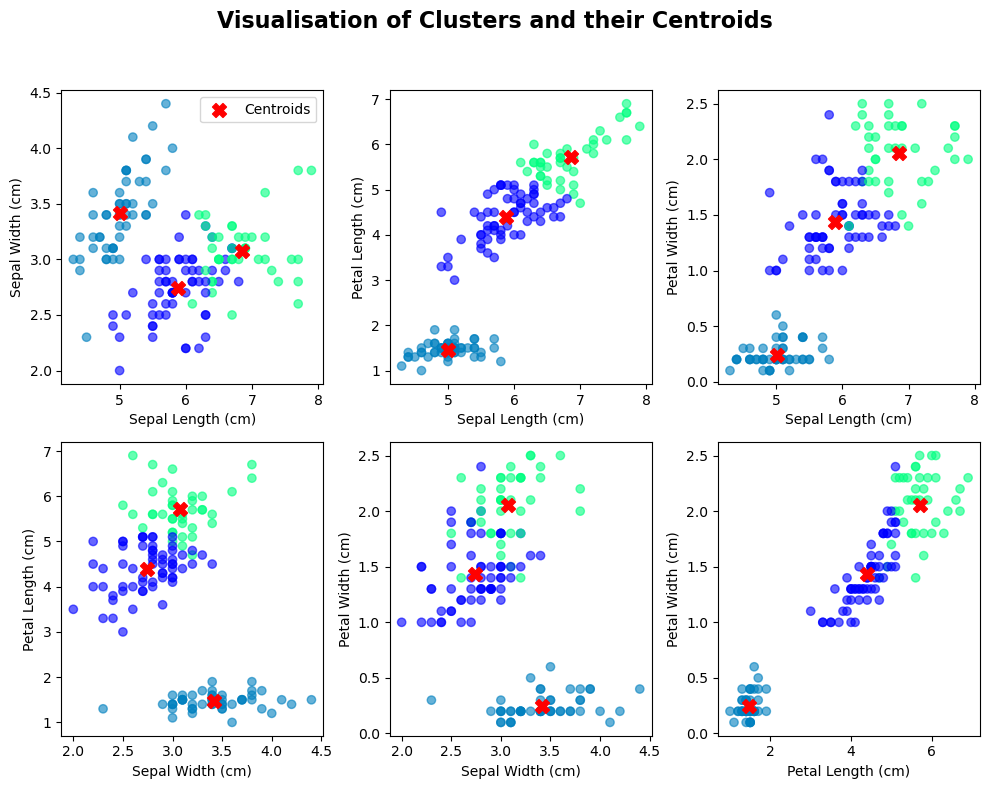

61 50 39


In [18]:
import pandas as pd
import numpy as np

M = 100  # points to be substituted with synthetic data
df = pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

cluster_assignments = kmeans(data_matrix, 3, 100)
plot_clusters(data_matrix, cluster_assignments, mean_clusters(data_matrix, cluster_assignments, 3))
print(np.sum(cluster_assignments == 0),
      np.sum(cluster_assignments == 1),
      np.sum(cluster_assignments == 2))

new_data = data_matrix.copy()
steps = 50  # Number of iterations

for i in range(steps):
    means = mean_clusters(new_data, cluster_assignments, 3)
    variances = variance_clusters(new_data, cluster_assignments, 3)
    
    # Use new_data instead of data_matrix, and sqrt(variances) for std
    new_data = update_dataset(new_data, cluster_assignments, M, means, np.sqrt(variances))
    
    cluster_assignments = kmeans(new_data, 3, 100)


<h3>After the closed-loop learning cycle:</h3>

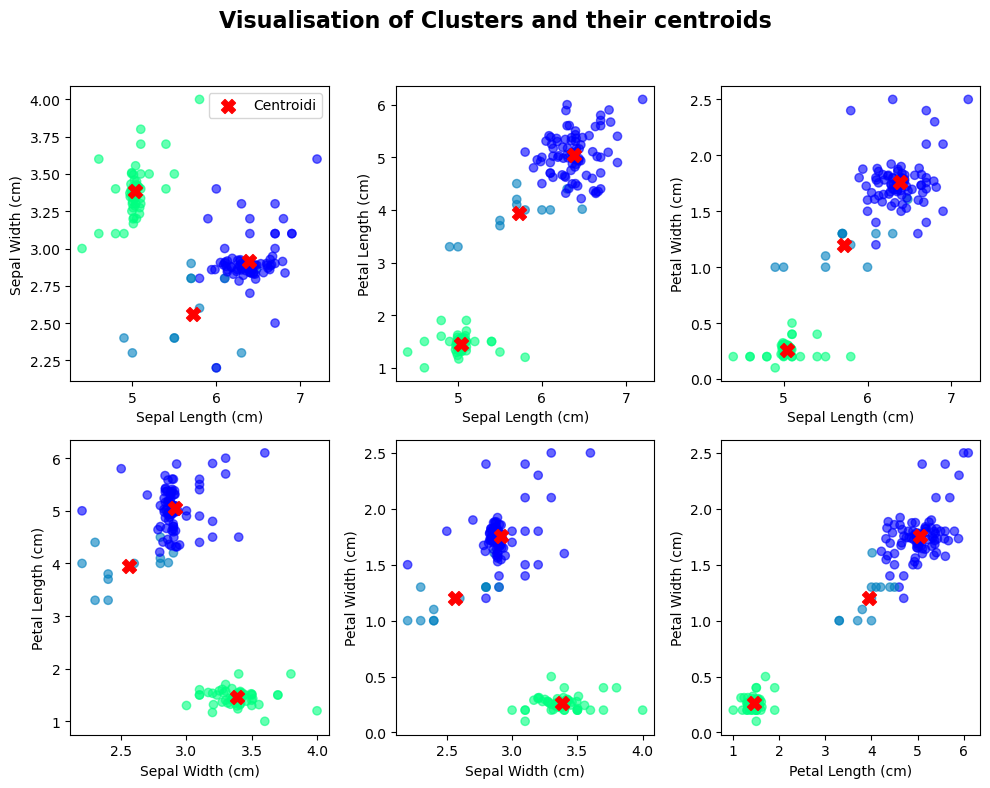

84 12 54


In [7]:
plot_clusters(new_data,cluster_assignments,mean_clusters(new_data,cluster_assignments, 3))
print(np.sum(cluster_assignments==0),np.sum(cluster_assignments==1),np.sum(cluster_assignments==2))

<h3>Purity score:</h3>

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, davies_bouldin_score

def infomax(labels):
    """Entropy of cluster label distribution."""
    M = len(labels)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / M
    H = -np.sum(probs * np.log(probs))
    return H

def purity_score(y_true, y_pred):
    """
    Compute purity between true labels and clustering assignments.
    """
    contingency_matrix = confusion_matrix(y_true, y_pred)
    max_per_cluster = contingency_matrix.max(axis=0)
    purity = max_per_cluster.sum() / contingency_matrix.sum()
    return purity

def fixed_kmeans(data_matrix, initial_centroids, steps):
    """K-means with fixed initial centroids (vectorized)."""
    centroids = initial_centroids.copy()
    
    for _ in range(steps):
        # Compute distance matrix (points × centroids) using broadcasting
        distances = np.linalg.norm(
            data_matrix[:, None, :] - centroids[None, :, :],
            axis=2
        )
        # Assign clusters
        cluster_assignments = np.argmin(distances, axis=1)
        
        # Update centroids (vectorized mean per cluster)
        for j in range(centroids.shape[0]):
            points_in_cluster = data_matrix[cluster_assignments == j]
            if points_in_cluster.size > 0:
                centroids[j] = points_in_cluster.mean(axis=0)
    
    return cluster_assignments, centroids


# --- Workflow ---
df = pd.read_csv('Iris.csv')
selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

# Use centroids from previous clustering (CLL)
initial_centroids = mean_clusters(data_matrix, np.zeros(data_matrix.shape[0]), 3)  # placeholder

# Run fixed K-means
cluster_assignments, centroids = fixed_kmeans(data_matrix, initial_centroids, steps=30)

print("Clustering assignments:", cluster_assignments)

ground_truth = np.array([0]*50 + [1]*50 + [2]*50)

print("Purity score of CLL:", purity_score(ground_truth, cluster_assignments))
print("Confusion matrix:\n", confusion_matrix(ground_truth, cluster_assignments))
print("Davies-Bouldin score of CLL:", davies_bouldin_score(data_matrix, cluster_assignments))
print("Infomax score of CLL:", infomax(cluster_assignments))


Clustering assignments: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1
 1 0]
Purity score of CLL: 0.8866666666666667
Confusion matrix:
 [[ 0  0 50]
 [47  3  0]
 [14 36  0]]
Davies-Bouldin score of CLL: 0.6663912107101473
Infomax score of CLL: 1.082346226196019


In [43]:
def purity_random_initialization_CLL(data_matrix, n_clusters, steps, M, n_iterations, ground_truth):
    """
    Run CLL clustering with random initializations and track metrics.
    
    Parameters:
    - data_matrix: ndarray, dataset
    - n_clusters: int, number of clusters
    - steps: int, number of CLL iterations
    - M: int, number of synthetic points to substitute
    - n_iterations: int, number of random initializations
    - ground_truth: ndarray, true labels for purity
    
    Returns:
    - all_purities, all_db, all_infomax: lists of metric curves
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    it = np.arange(1, steps + 1)
    all_purities, all_db, all_infomax = [], [], []
    
    for _ in range(n_iterations):
        purity_curve = np.zeros(steps)
        db_curve = np.zeros(steps)
        infomax_curve = np.zeros(steps)
        
        # Initial clustering
        cluster_assignments = kmeans(data_matrix, n_clusters, 30)
        new_data = data_matrix.copy()
        
        for i in range(steps):
            # Compute cluster statistics
            means = mean_clusters(new_data, cluster_assignments, n_clusters)
            variances = variance_clusters(new_data, cluster_assignments, n_clusters)
            
            # Update dataset with synthetic points (only if M > 0)
            if M > 0:
                new_data = update_dataset(new_data, cluster_assignments, M, means, np.sqrt(variances))
            
            # Re-run clustering on ORIGINAL dataset
            cluster_assignments_final, _ = fixed_kmeans(data_matrix, means, 30)
            
            # Purity
            purity_curve[i] = purity_score(ground_truth, cluster_assignments_final)
            
            # Davies-Bouldin (only if >1 cluster)
            if len(np.unique(cluster_assignments_final)) > 1:
                db_curve[i] = davies_bouldin_score(data_matrix, cluster_assignments_final)
            else:
                db_curve[i] = np.nan
            
            # Infomax
            infomax_curve[i] = infomax(cluster_assignments_final)
        
        all_purities.append(purity_curve)
        all_db.append(db_curve)
        all_infomax.append(infomax_curve)
    
    # --- Plotting helper ---
    def plot_metric(metric_curves, title, ylabel, filename):
        plt.figure(figsize=(10, 6))
        for curve in metric_curves:
            plt.plot(it, curve, alpha=0.5)
        plt.title(title)
        plt.xlabel("Iteration count")
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(filename, format="pdf")
        plt.show()
    
    plot_metric(all_purities, "Purity score convergence", "Purity score", "purity_vs_iteration.pdf")
    plot_metric(all_db, "D-B score convergence", "DB-index score", "db_vs_iteration.pdf")
    plot_metric(all_infomax, "Infomax-score convergence", "Infomax score", "infomax_vs_iteration.pdf")
    
    return all_purities, all_db, all_infomax



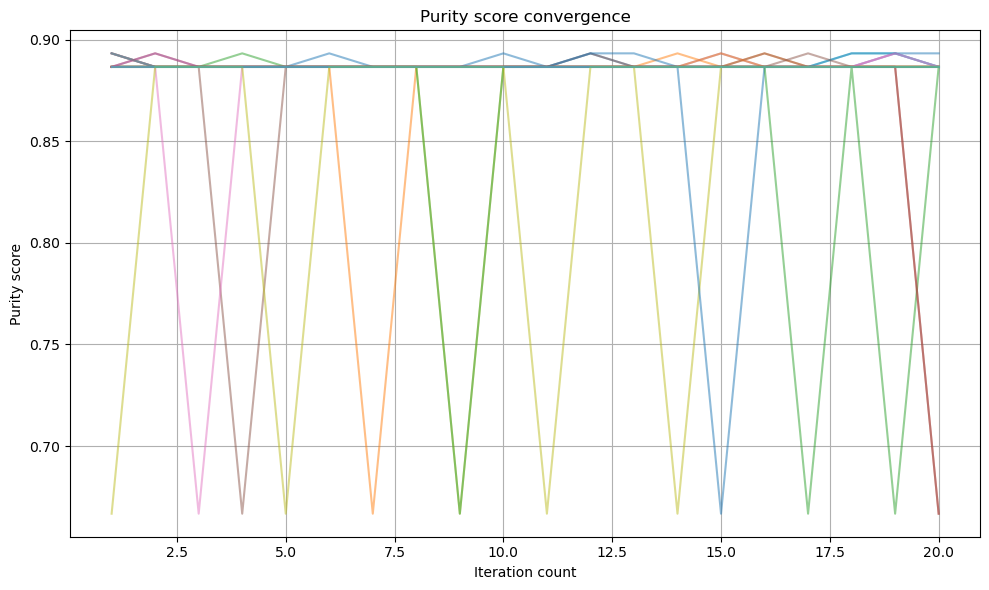

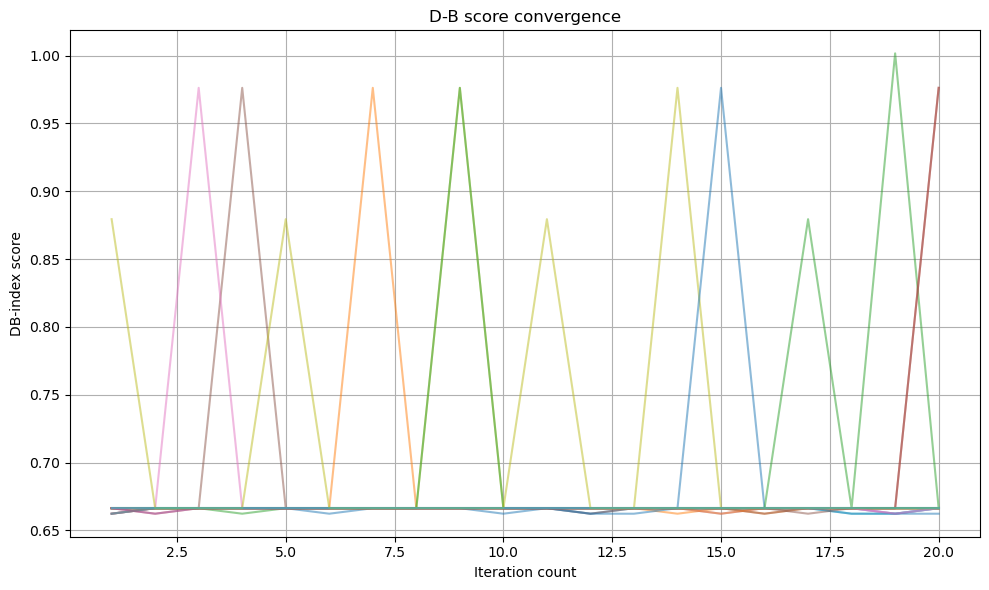

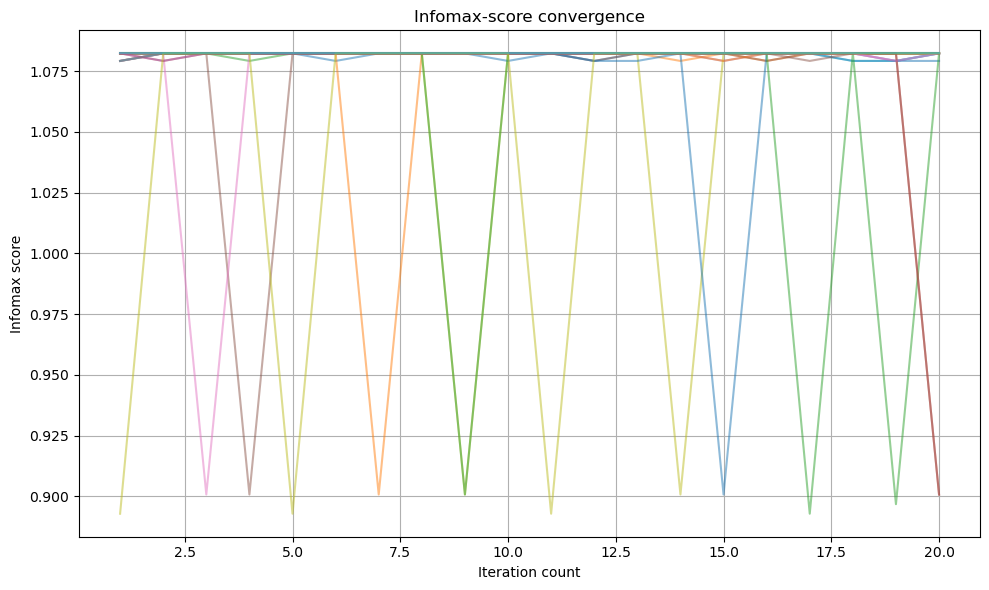

([array([0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.89333333, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.89333333, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.89333333, 0.88666667]),
  array([0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.66666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.89333333, 0.88666667,
         0.89333333, 0.88666667, 0.88666667, 0.88666667, 0.88666667]),
  array([0.88666667, 0.88666667, 0.88666667, 0.89333333, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667]),
  array([0.89333333, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
         0.88666667, 0.88666

In [44]:
df=pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()
ground_truth = np.array([0]*50 + [1]*50 + [2]*50)


purity_random_initialization_CLL(data_matrix, n_clusters=3,steps=20,M=20,n_iterations=20,ground_truth=ground_truth)

In [45]:
def indexes_vs_M_CLL(data_matrix, n_clusters, steps, ground_truth):
    """
    Evaluate clustering metrics (Purity, DB-index, Infomax) as a function of M.
    Re-run clustering is always performed on the original dataset.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    M_values = np.arange(150)  # all natural numbers from 0 to 149
    
    purity = np.zeros(len(M_values))
    db_index = np.zeros(len(M_values))
    infomax_index = np.zeros(len(M_values))
    
    for j, M in enumerate(M_values):
        cluster_assignments = kmeans(data_matrix, n_clusters, 30)
        new_data = data_matrix.copy()
        
        for _ in range(steps):
            means = mean_clusters(new_data, cluster_assignments, n_clusters)
            variances = variance_clusters(new_data, cluster_assignments, n_clusters)
            
            if M > 0:
                new_data = update_dataset(new_data, cluster_assignments, M, means, np.sqrt(variances))
            
            # Re-run clustering on the ORIGINAL dataset
            cluster_assignments = kmeans(data_matrix, n_clusters, 30)
            cluster_assignments, _ = fixed_kmeans(data_matrix, means, 30)
        
        # --- Metrics ---
        purity[j] = purity_score(ground_truth, cluster_assignments)
        unique_labels = np.unique(cluster_assignments)
        db_index[j] = davies_bouldin_score(data_matrix, cluster_assignments) if len(unique_labels) > 1 else np.nan
        infomax_index[j] = infomax(cluster_assignments)
    
    # --- Plotting helper ---
    def plot_metric(x, y, title, ylabel, filename):
        plt.figure(figsize=(10, 6))
        plt.plot(x, y, marker='o')
        plt.title(title)
        plt.xlabel("M (synthetic points substituted)")
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(filename, format="pdf")
        plt.show()
    
    plot_metric(M_values, purity, "Purity vs M", "Purity score", "purity_vs_M.pdf")
    plot_metric(M_values, db_index, "Davies-Bouldin vs M", "DB-index score", "db_vs_M.pdf")
    plot_metric(M_values, infomax_index, "Infomax vs M", "Infomax score", "infomax_vs_M.pdf")
    
    return purity, db_index, infomax_index



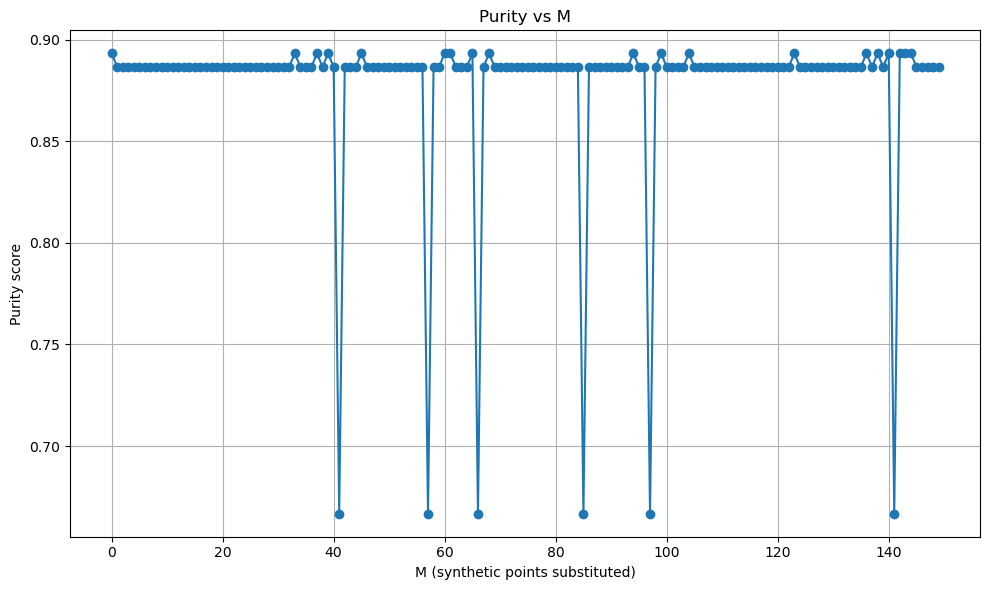

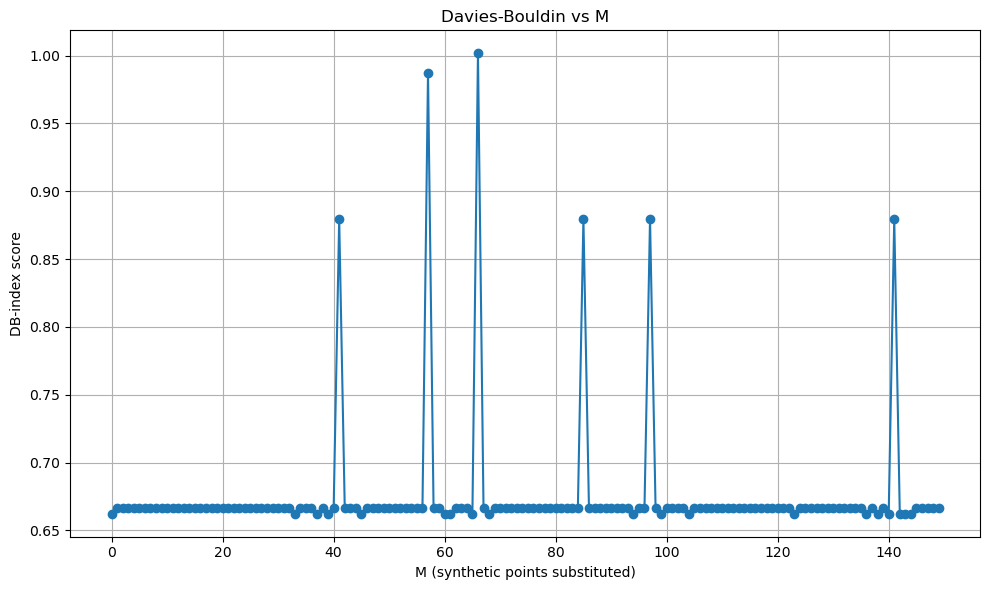

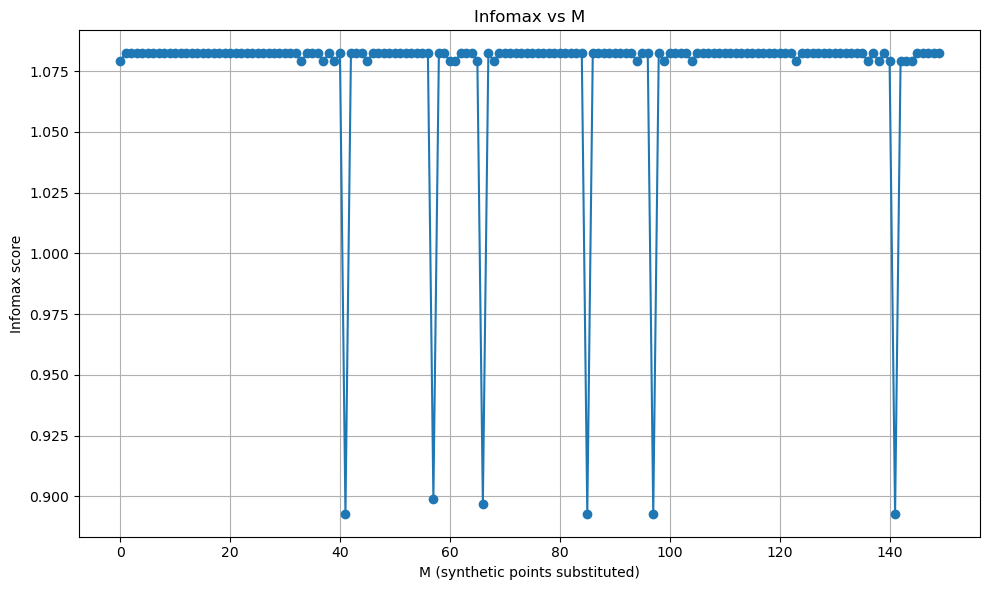

(array([0.89333333, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.89333333, 0.88666667,
        0.88666667, 0.88666667, 0.89333333, 0.88666667, 0.89333333,
        0.88666667, 0.66666667, 0.88666667, 0.88666667, 0.88666667,
        0.89333333, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88666667, 0.88666667,
        0.88666667, 0.88666667, 0.66666667, 0.88666667, 0.88666667,
        0.89333333, 0.89333333, 0.88666667, 0.88666667, 0.88666667,
        0.89333333, 0.66666667, 0.88666667, 0.89333333, 0.88666667,
        0.88666667, 0.88666667, 0.88666667, 0.88

In [46]:
df=pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()
ground_truth = np.array([0]*50 + [1]*50 + [2]*50)
indexes_vs_M_CLL(data_matrix, n_clusters=3,steps=15,ground_truth=ground_truth)